In [1]:
import pandas as pd
import numpy as np
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import datetime
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
symbols = ['CUUR0000SETA01', 'DFINCP', 'DTCTLVENANM']
start = datetime.datetime(2010, 12, 1)
end = datetime.datetime(2024, 12, 1)
df = web.DataReader(symbols, 'fred', start, end)
print(df)

            CUUR0000SETA01      DFINCP  DTCTLVENANM
DATE                                               
2010-12-01         138.567  302.946146     25261.78
2010-12-08             NaN  296.449070          NaN
2010-12-15             NaN  283.789222          NaN
2010-12-22             NaN  275.473732          NaN
2010-12-29             NaN  262.638221          NaN
...                    ...         ...          ...
2024-11-06             NaN  226.051484          NaN
2024-11-13             NaN  222.981531          NaN
2024-11-20             NaN  226.875516          NaN
2024-11-27             NaN  224.165875          NaN
2024-12-01         177.552         NaN     39979.23

[875 rows x 3 columns]


Данные включают следующие показатели:

CUUR0000SETA01: Индекс потребительских цен (CPI) на автомобили.

DFINCP: Индекс цепных цен личных потребительских расходов на финансовые услуги.

DTCTLVENANM: Общий объем потребительских кредитов на автомобили (миллионы долларов США).

<ipython-input-3-031469383fea>:2: FutureWarning: The 'convention' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast PeriodIndex to DatetimeIndex before resampling instead.
  df000 = df.resample('Q', convention='start').last().dropna()
<ipython-input-3-031469383fea>:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  df000 = df.resample('Q', convention='start').last().dropna()


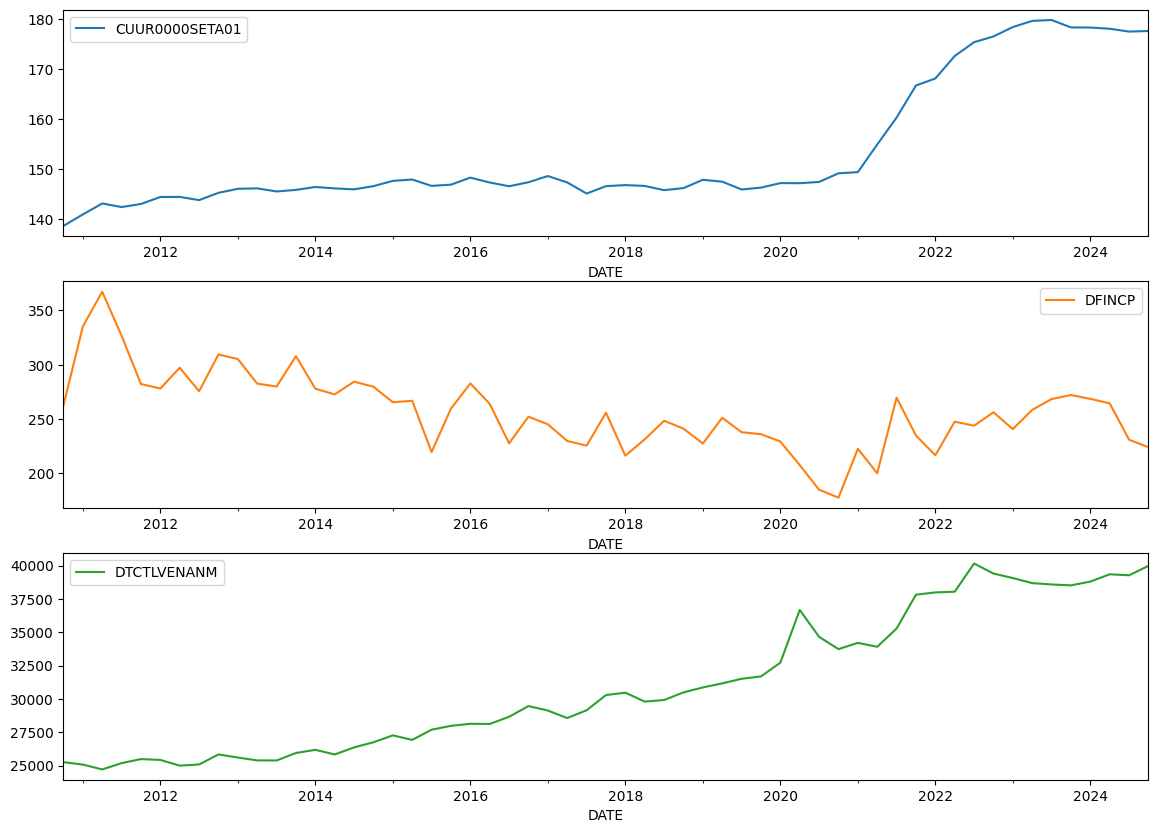

In [3]:
#Переведем данные в квартальные
df000 = df.resample('Q', convention='start').last().dropna()
df000.plot(subplots=True, layout=(3,1), figsize=(14,10), sharex=False, sharey=False)
plt.show()

CUUR0000SETA01: Индекс потребительских цен (CPI) на автомобили демонстрирует рост, особенно заметный с 2020 года, с выходом на относительно стабильный уровень к 2023-2024 гг.

DFINCP: Индекс цепных цен на финансовые услуги показывает общее снижение с некоторыми периодическими колебаниями.

DTCTLVENANM: Общий объем потребительских кредитов на автомобили стабильно растёт с течением времени, указывая на постоянное увеличение потребительского спроса.

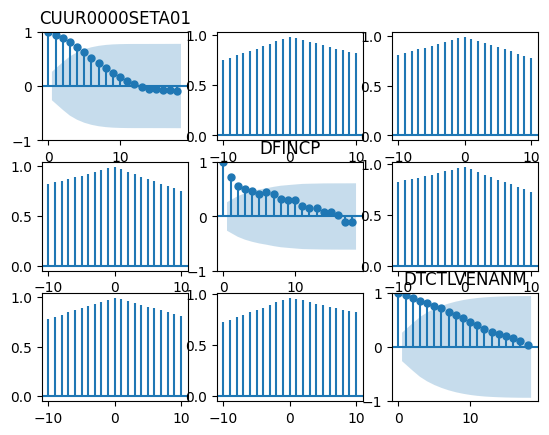

In [ ]:
data = np.log(df000).diff().dropna()
#анализируем структуру ряда динамики на основе автокорреляций и частных автокорреляций
fig, axes = plt.subplots(nrows=3, ncols=3, sharex=False)
for i in range(len(symbols)):
   plot_acf(df000.values[:,i],
   ax=axes[i,i],
   label=symbols[i]);
   axes[i,i].set_title(symbols[i])

axes[1, 0].xcorr(df000.values[:,1], df000.values[:,0])
axes[2, 0].xcorr(df000.values[:,2], df000.values[:,0])
axes[2, 1].xcorr(df000.values[:,2], df000.values[:,1])
axes[0, 1].xcorr(df000.values[:,0], df000.values[:,1])
axes[0, 2].xcorr(df000.values[:,0], df000.values[:,2])
axes[1, 2].xcorr(df000.values[:,1], df000.values[:,2])
plt.show()

CUUR0000SETA01 и DTCTLVENANM показывают высокую автокорреляцию, медленно снижающуюся с ростом лага, что свидетельствует о наличии долгосрочной зависимости в данных.

DFINCP также демонстрирует выраженную автокорреляцию с постепенным затуханием.


In [ ]:
model = VAR(data)
results = model.fit(2)
results.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 06, Mar, 2025
Time:                     06:15:01
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -20.7258
Nobs:                     53.0000    HQIC:                  -21.2062
Log likelihood:           365.309    FPE:                4.59087e-10
AIC:                     -21.5064    Det(Omega_mle):     3.16423e-10
--------------------------------------------------------------------
Results for equation CUUR0000SETA01
                       coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------------
const                     0.001216         0.001572            0.774           0.439
L1.CUUR0000SETA01         0.438754         0.152280            2.881           0.004
L1.DFINCP                 0.008195 

CUUR0000SETA01 имеет устойчивую динамику и объясняется преимущественно собственной историей.

DFINCP зависит от собственной динамики, а также существенно реагирует на изменения инфляции на автомобили и объемов автокредитования, что делает эту переменную наиболее чувствительной к изменениям других переменных.

DTCTLVENANM (кредиты на автомобили) слабо зависит от остальных переменных и в основном определяется собственной динамикой и восходящим трендом.

С помощью корреляционной матрицы можно выяснить, что несущественная зависимость есть между показателями индекса потребительских цен (CPI) на автомобили и индекса цепных цен личных потребительских расходов на финансовые услуги.


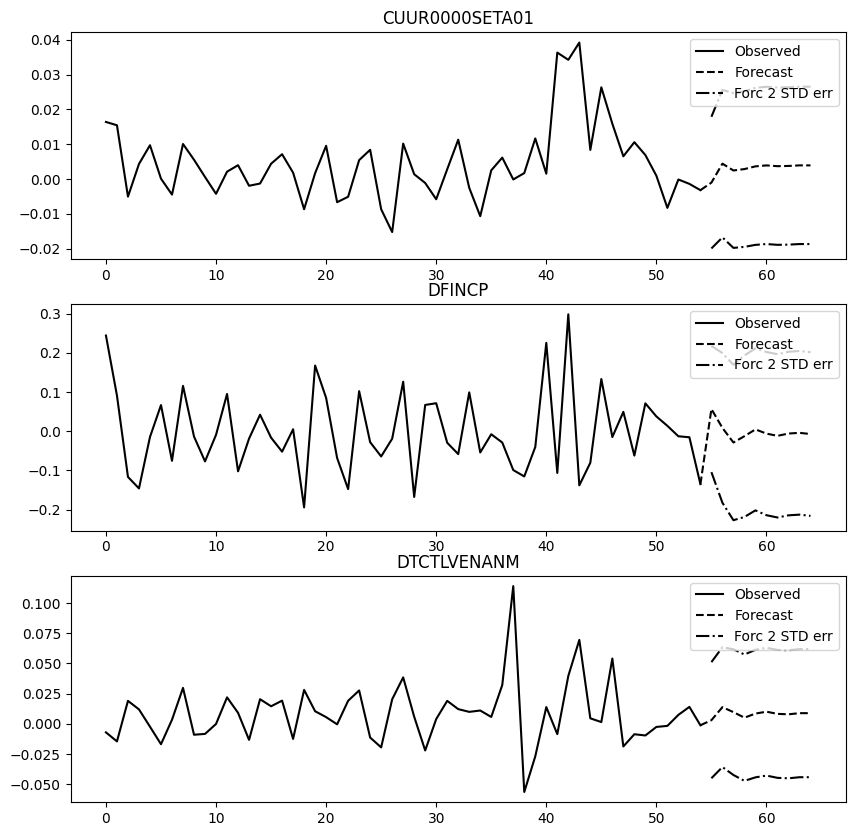

In [ ]:
lag_order = results.k_ar
results.forecast(data.values[-lag_order:], 10)
results.plot_forecast(10)
plt.show()

В краткосрочной перспективе все три временных ряда стремятся к стабилизации без резких изменений.
Небольшие границы доверительных интервалов указывают на высокую точность прогноза.

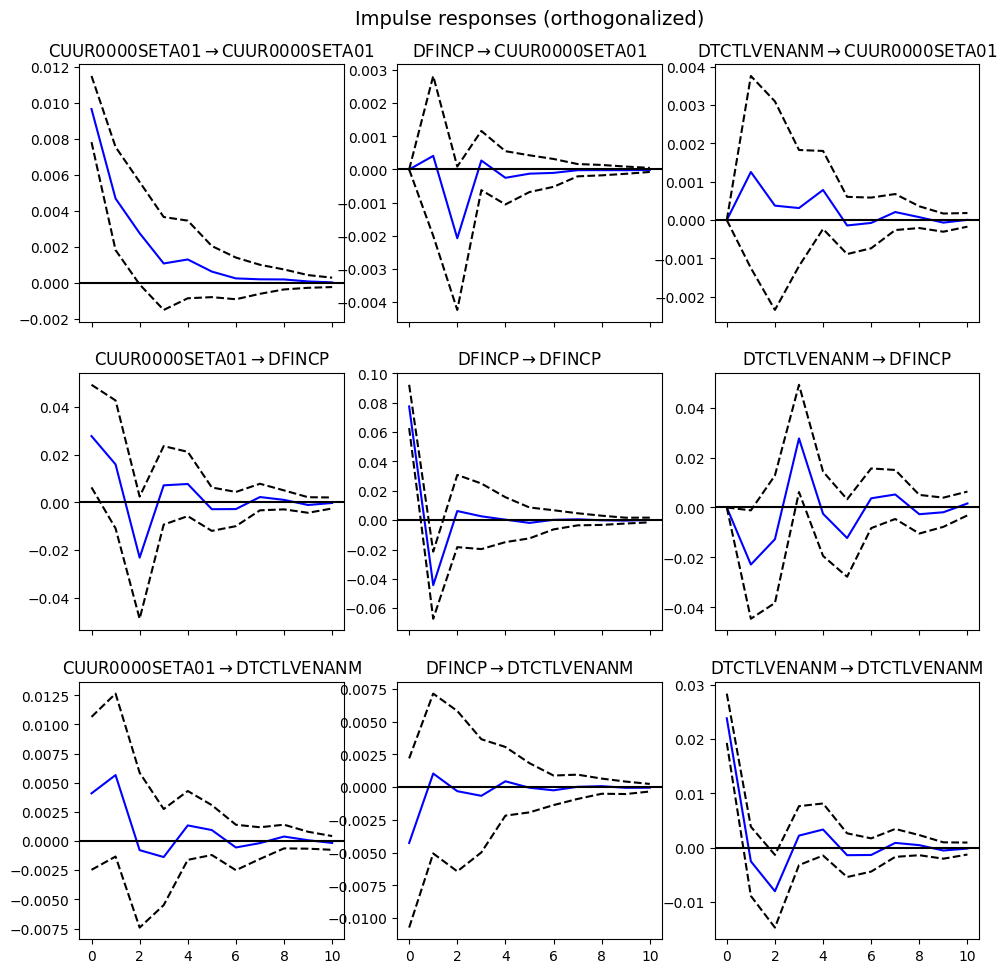

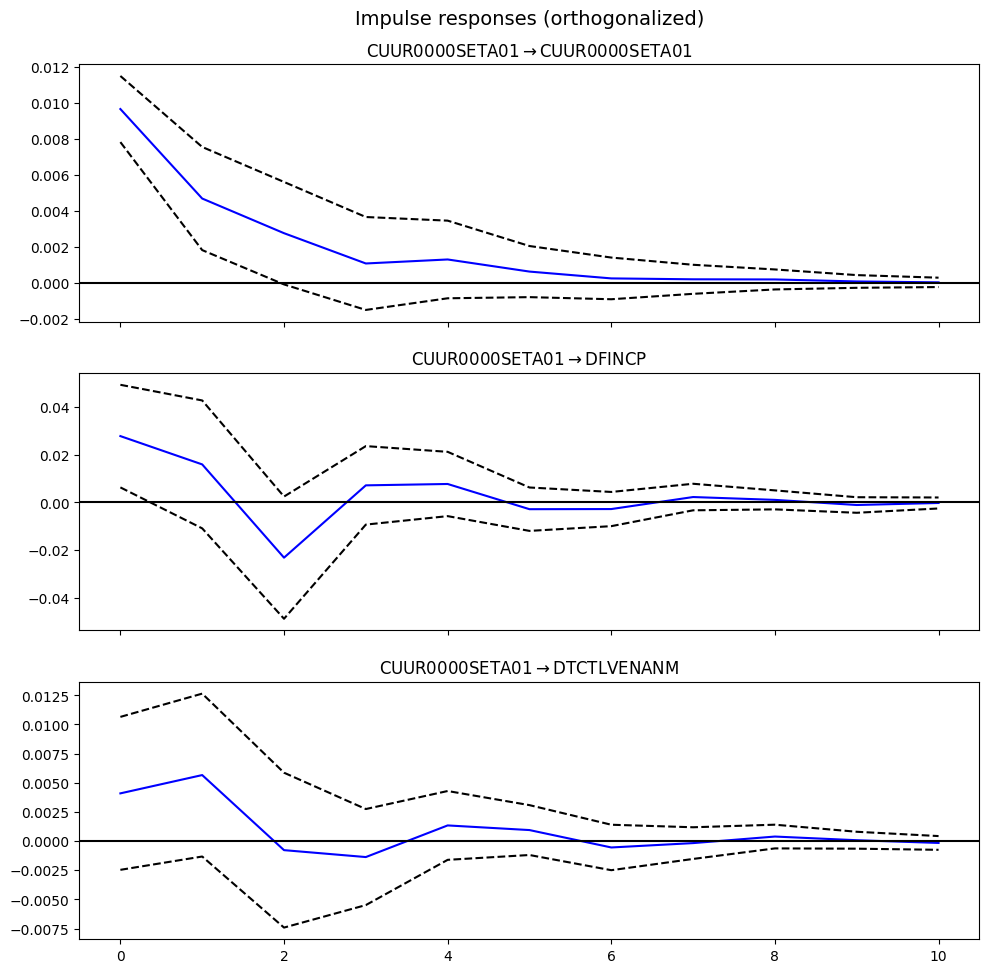

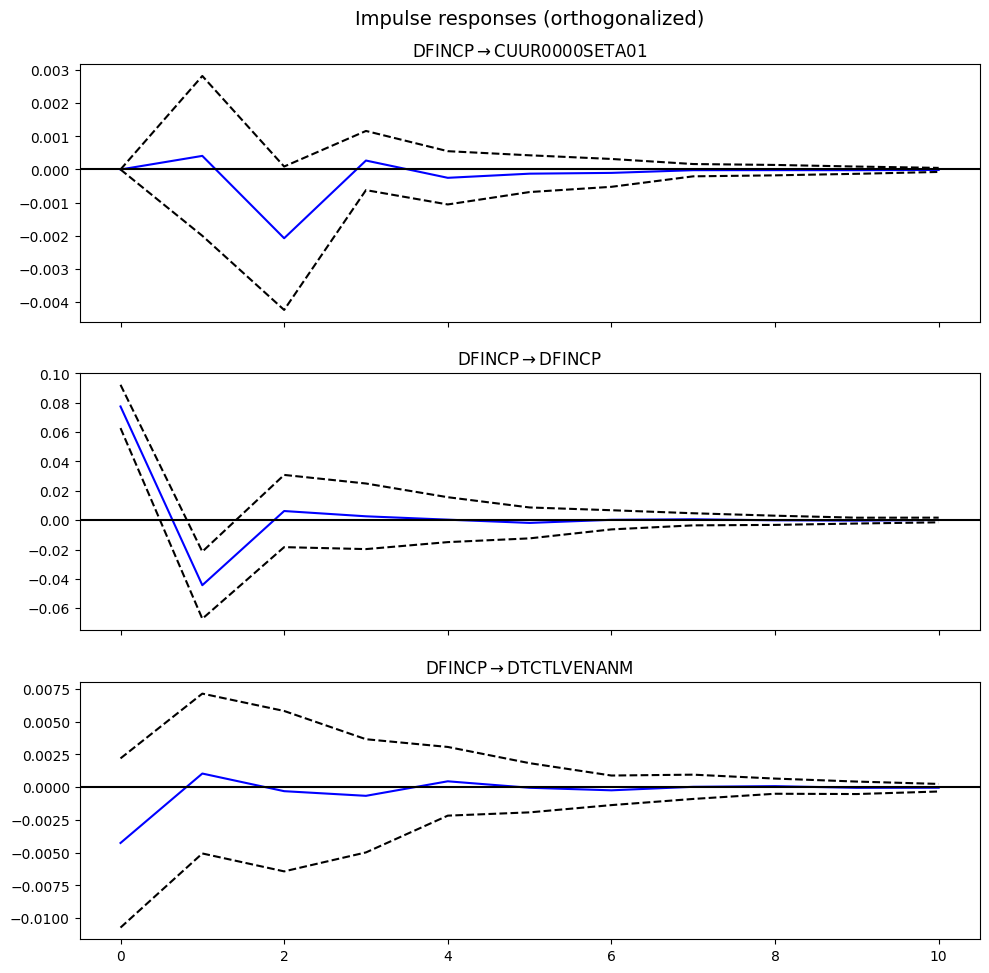

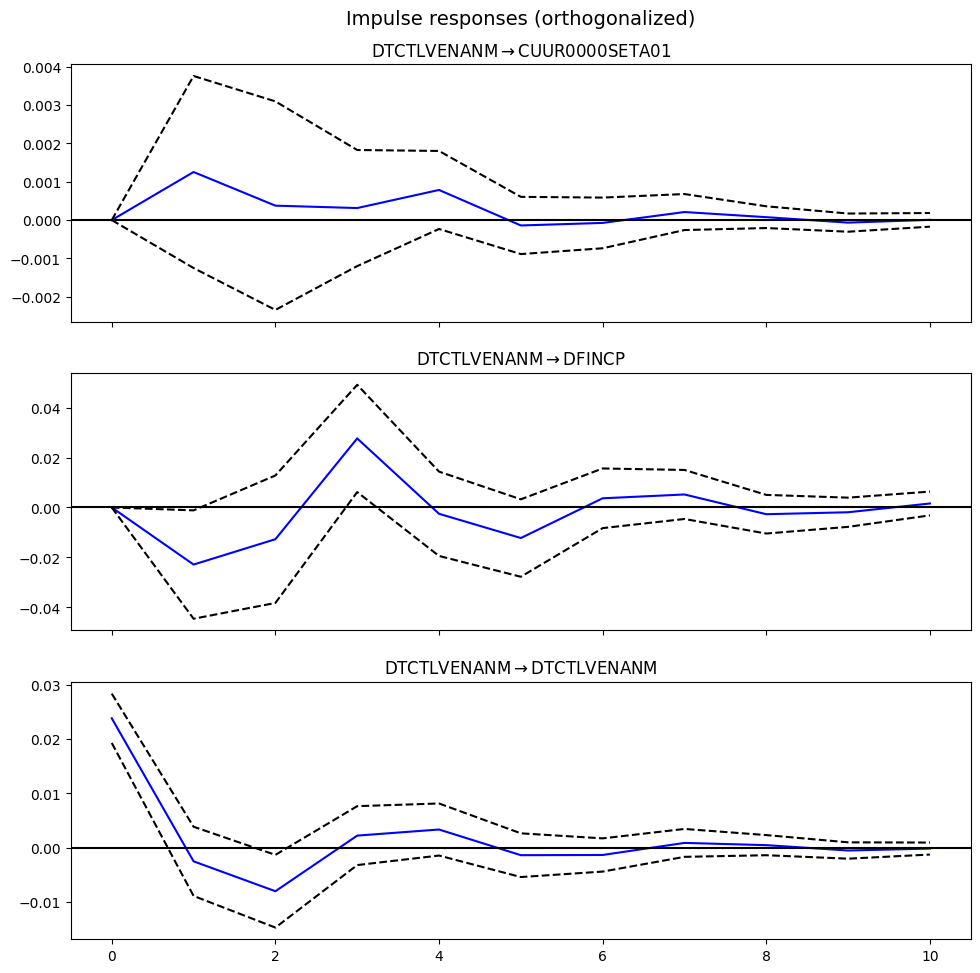

In [ ]:
# Создание VAR-модели
model = VAR(data)
results = model.fit(2)  # Количество лагов (замените при необходимости)

# Создание IRF-объекта
irf = results.irf(10)  # 10 шагов вперед
irf.plot(orth=True)
plt.show()

irf.plot(impulse='CUUR0000SETA01', orth=True)
plt.show()

irf.plot(impulse='DFINCP', orth=True)
plt.show()

irf.plot(impulse='DTCTLVENANM', orth=True)
plt.show()

Цены на финансовые услуги (DFINCP) наиболее чувствительны к изменениям других переменных (особенно к индексам автомобильных цен и кредитам).

Индекс цен автомобилей (CUUR0000SETA01) и кредиты на автомобили (DTCTLVENANM) относительно устойчивы к изменениям других переменных, но имеют выраженную собственную инерцию.

Влияние большинства переменных затухает к 5-6 периоду, что говорит о краткосрочном характере межпеременных влияний.

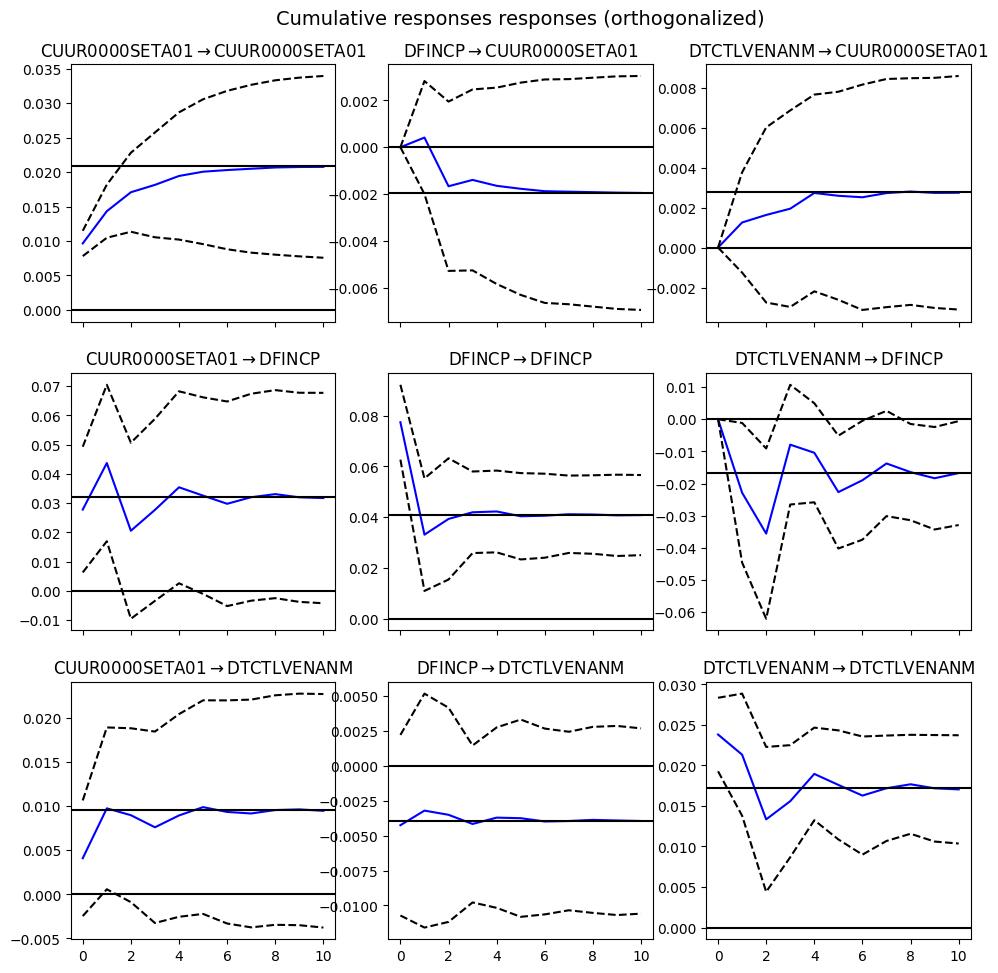

In [ ]:
irf.plot_cum_effects(orth=True)
plt.show()

Наибольший долгосрочный эффект оказывают внутренние (собственные) шоки в каждой переменной.
Цены на финансовые услуги чувствительны к изменениям в индексе цен автомобилей и объемах кредитования.
Индекс цен на автомобили и объемы кредитов демонстрируют умеренное долгосрочное взаимодействие друг с другом.
Финансовые услуги оказывают минимальное долговременное влияние на остальные показатели.